# LSTM — Modelo Principal e Experimento com USD/BRL(t)

Notebook modular para executar a LSTM mantendo a mesma estrutura experimental dos notebooks de Regressão Linear e Random Forest.

**Configuração padrão:** modelo principal com as 9 variáveis explicativas. O experimento com `USD/BRL(t)` pode ser ativado alterando `EXPERIMENTO_USD_T = True`.

O notebook preserva a divisão temporal 80/20, o mesmo target `USD_BRL_t1` e os mesmos períodos de treino/teste.

## Etapa 1 — Configuração dos caminhos e experimento

A base definitiva é carregada com a primeira coluna como índice. A divisão treino/teste é feita pela função de apoio fornecida, mantendo a ordem temporal.

In [ ]:
from pathlib import Path

# ============================================================
# CONFIGURAÇÃO DO EXPERIMENTO
# ============================================================

EXPERIMENTO_USD_T = True

PROJECT_ROOT = Path(r"C:\Projetos\PTAX_PREDICTION_MBA_TCC")

PATH_FILE = (
    PROJECT_ROOT
    / "dados"
    / "tratado"
    / "consolidado_sem_nulos_final_usdt1.csv"
)

if EXPERIMENTO_USD_T:
    PATH_TO_SAVE = (
        PROJECT_ROOT
        / "resultados"
        / "lstm"
        / "experimento_usd_t"
    )
else:
    PATH_TO_SAVE = (
        PROJECT_ROOT
        / "resultados"
        / "lstm"
        / "modelo_principal"
    )

PATH_TO_SAVE.mkdir(parents=True, exist_ok=True)

print(f"[INFO] Base: {PATH_FILE}")
print(f"[INFO] Resultados: {PATH_TO_SAVE}")
print(f"[INFO] Experimento USD/BRL(t): {EXPERIMENTO_USD_T}")

[INFO] Base: C:\Projetos\PTAX_PREDICTION_MBA_TCC\dados\tratado\consolidado_sem_nulos_final_usdt1.csv
[INFO] Resultados: C:\Projetos\PTAX_PREDICTION_MBA_TCC\resultados\lstm\experimento_usd_t
[INFO] Experimento USD/BRL(t): True


## Etapa 2 — Importação das bibliotecas

In [19]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

from arquivos_apoio.funcoes_apoio import dividir_treino_teste_tcc

print(f"[OK] TensorFlow: {tf.__version__}")
print("[OK] Bibliotecas importadas.")

[OK] TensorFlow: 2.21.0
[OK] Bibliotecas importadas.


## Etapa 3 — Carregamento, preparação da base e divisão temporal treino/teste

A função de apoio utiliza 80% das observações para treinamento e 20% para teste, preservando a ordem cronológica e sem embaralhamento. Ela também permite alternar entre o modelo principal e o experimento com `USD/BRL(t)`.

In [20]:
X_train, y_train, X_test, y_test = dividir_treino_teste_tcc(
    caminho_csv=str(PATH_FILE),
    incluir_usd_t=EXPERIMENTO_USD_T,
    proporcao_treino=0.80
)

target = "USD_BRL_t1"

print("\n[OK] Dados preparados.")
print(f"[INFO] X_train: {X_train.shape}")
print(f"[INFO] y_train: {y_train.shape}")
print(f"[INFO] X_test:  {X_test.shape}")
print(f"[INFO] y_test:  {y_test.shape}")

[OK] Base carregada.
[INFO] Dimensões iniciais: (2600, 11)
[OK] Índice convertido para DatetimeIndex.
[OK] Base ordenada cronologicamente.
[OK] Não existem valores nulos.
[OK] Não existem valores infinitos.

DIVISÃO TREINO / TESTE
[INFO] Configuração: Experimento com USD/BRL(t)
[INFO] Variáveis explicativas: 10
[INFO] Variáveis: ['Selic', 'IPCA', 'PIB', 'Exportacoes', 'Importacoes', 'FEDFUNDS', 'IBOV', 'SP500', 'Petroleo', 'USD/BRL']
[INFO] Observações totais: 2600
[INFO] Treino: 2080 (80.0%)
[INFO] Teste: 520 (20.0%)
[INFO] Período treino: 2016-05-02 a 2024-04-24
[INFO] Período teste: 2024-04-25 a 2026-04-29
[OK] Ordem temporal preservada.
[OK] Sem sobreposição temporal.
[OK] Target: USD_BRL_t1

[OK] Dados preparados.
[INFO] X_train: (2080, 10)
[INFO] y_train: (2080,)
[INFO] X_test:  (520, 10)
[INFO] y_test:  (520,)


## Etapa 4 — Validação final dos dados antes do treinamento

In [21]:
print("=" * 70)
print("VALIDAÇÃO DOS DADOS")
print("=" * 70)

print(f"[OK] X_train é DataFrame: {isinstance(X_train, pd.DataFrame)}")
print(f"[OK] X_test é DataFrame:  {isinstance(X_test, pd.DataFrame)}")
print(f"[OK] y_train é Series:    {isinstance(y_train, pd.Series)}")
print(f"[OK] y_test é Series:     {isinstance(y_test, pd.Series)}")

print(f"\n[INFO] Variáveis explicativas ({len(X_train.columns)}):")
print(list(X_train.columns))

if not isinstance(X_train.index, pd.DatetimeIndex):
    raise TypeError("X_train deve possuir DatetimeIndex.")

if not isinstance(X_test.index, pd.DatetimeIndex):
    raise TypeError("X_test deve possuir DatetimeIndex.")

if not X_train.index.is_monotonic_increasing:
    raise ValueError("X_train não está em ordem cronológica.")

if not X_test.index.is_monotonic_increasing:
    raise ValueError("X_test não está em ordem cronológica.")

if X_train.index.max() >= X_test.index.min():
    raise ValueError("Existe sobreposição temporal entre treino e teste.")

if X_train.isna().any().any() or X_test.isna().any().any():
    raise ValueError("Existem valores nulos em X.")

if y_train.isna().any() or y_test.isna().any():
    raise ValueError("Existem valores nulos em y.")

if np.isinf(X_train.to_numpy(dtype=float)).any():
    raise ValueError("Existem valores infinitos em X_train.")

if np.isinf(X_test.to_numpy(dtype=float)).any():
    raise ValueError("Existem valores infinitos em X_test.")

print(f"\n[INFO] Treino: {X_train.index.min().date()} a {X_train.index.max().date()}")
print(f"[INFO] Teste:  {X_test.index.min().date()} a {X_test.index.max().date()}")
print("[OK] Sem NaN.")
print("[OK] Sem valores infinitos.")
print("[OK] Ordem temporal preservada.")
print("[OK] Sem sobreposição temporal.")

VALIDAÇÃO DOS DADOS
[OK] X_train é DataFrame: True
[OK] X_test é DataFrame:  True
[OK] y_train é Series:    True
[OK] y_test é Series:     True

[INFO] Variáveis explicativas (10):
['Selic', 'IPCA', 'PIB', 'Exportacoes', 'Importacoes', 'FEDFUNDS', 'IBOV', 'SP500', 'Petroleo', 'USD/BRL']

[INFO] Treino: 2016-05-02 a 2024-04-24
[INFO] Teste:  2024-04-25 a 2026-04-29
[OK] Sem NaN.
[OK] Sem valores infinitos.
[OK] Ordem temporal preservada.
[OK] Sem sobreposição temporal.


## Etapa 5 — Padronização de X e y

A LSTM utiliza `StandardScaler` tanto para as variáveis explicativas quanto para o target. Os dois scalers são ajustados **exclusivamente no conjunto de treino** e depois aplicados ao teste.

In [22]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(
    y_train.to_numpy(dtype=float).reshape(-1, 1)
)
y_test_scaled = scaler_y.transform(
    y_test.to_numpy(dtype=float).reshape(-1, 1)
)

joblib.dump(scaler_X, PATH_TO_SAVE / "standard_scaler_X.joblib")
joblib.dump(scaler_y, PATH_TO_SAVE / "standard_scaler_y.joblib")

print("[OK] StandardScaler de X ajustado somente no treino.")
print("[OK] StandardScaler de y ajustado somente no treino.")
print(f"[INFO] X_train_scaled: {X_train_scaled.shape}")
print(f"[INFO] X_test_scaled:  {X_test_scaled.shape}")
print(f"[INFO] y_train_scaled: {y_train_scaled.shape}")
print(f"[INFO] y_test_scaled:  {y_test_scaled.shape}")

[OK] StandardScaler de X ajustado somente no treino.
[OK] StandardScaler de y ajustado somente no treino.
[INFO] X_train_scaled: (2080, 10)
[INFO] X_test_scaled:  (520, 10)
[INFO] y_train_scaled: (2080, 1)
[INFO] y_test_scaled:  (520, 1)


## Etapa 6 — Construção das sequências temporais de treino

**Janela:** 30 observações.

Para manter o alinhamento com o target já definido como `USD/BRL(t+1)`, cada janela utiliza as observações de `X` dos 30 dias até `t` para prever `y` na mesma linha, que representa `USD/BRL(t+1)`.

In [23]:
WINDOW = 30

def criar_sequencias_treino(X_scaled, y_scaled, datas, window=30):
    X_scaled = np.asarray(X_scaled)
    y_scaled = np.asarray(y_scaled).reshape(-1)
    datas = pd.DatetimeIndex(datas)

    if len(X_scaled) != len(y_scaled) or len(X_scaled) != len(datas):
        raise ValueError("X, y e datas devem possuir o mesmo número de observações.")

    if len(X_scaled) <= window:
        raise ValueError("Não há observações suficientes para a janela definida.")

    X_seq = []
    y_seq = []
    datas_target = []

    # X[i-window+1 : i+1] -> y[i] = USD/BRL(i+1)
    for i in range(window - 1, len(X_scaled)):
        X_seq.append(X_scaled[i - window + 1:i + 1])
        y_seq.append(y_scaled[i])
        datas_target.append(datas[i])

    return (
        np.asarray(X_seq),
        np.asarray(y_seq).reshape(-1, 1),
        pd.DatetimeIndex(datas_target)
    )

X_train_seq, y_train_seq, datas_train_seq = criar_sequencias_treino(
    X_train_scaled,
    y_train_scaled,
    X_train.index,
    WINDOW
)

print("=" * 70)
print("SEQUÊNCIAS DE TREINO")
print("=" * 70)
print(f"[INFO] Window: {WINDOW}")
print(f"[INFO] X_train_seq shape: {X_train_seq.shape}")
print(f"[INFO] y_train_seq shape: {y_train_seq.shape}")

print("\nVERIFICAÇÃO DA PRIMEIRA SEQUÊNCIA")
print(f"[INFO] Início da janela: {X_train.index[0].date()}")
print(f"[INFO] Fim da janela:    {X_train.index[WINDOW - 1].date()}")
print(f"[INFO] Data do target:   {X_train.index[WINDOW - 1].date()}")
print(f"[INFO] Data registrada:  {datas_train_seq[0].date()}")

if datas_train_seq[0] != X_train.index[WINDOW - 1]:
    raise ValueError("Erro no alinhamento temporal da primeira sequência.")

print("[OK] Primeira sequência validada.")

SEQUÊNCIAS DE TREINO
[INFO] Window: 30
[INFO] X_train_seq shape: (2051, 30, 10)
[INFO] y_train_seq shape: (2051, 1)

VERIFICAÇÃO DA PRIMEIRA SEQUÊNCIA
[INFO] Início da janela: 2016-05-02
[INFO] Fim da janela:    2016-06-10
[INFO] Data do target:   2016-06-10
[INFO] Data registrada:  2016-06-10
[OK] Primeira sequência validada.


## Etapa 7 — Construção das sequências temporais de teste

A primeira previsão do teste precisa usar apenas informação disponível até a data do primeiro registro de teste. Como `X_test[0]` representa as variáveis disponíveis em `t` e `y_test[0]` representa `USD/BRL(t+1)`, a primeira janela é formada pelas **29 últimas observações de treino + a primeira observação de teste**.

Depois da primeira previsão, cada nova observação de teste passa a integrar o histórico disponível para a previsão seguinte. Nenhum target futuro é utilizado como entrada.

In [24]:
def criar_sequencias_teste(
    X_train_scaled,
    X_test_scaled,
    y_test_scaled,
    datas_test,
    window=30
):
    X_train_scaled = np.asarray(X_train_scaled)
    X_test_scaled = np.asarray(X_test_scaled)
    y_test_scaled = np.asarray(y_test_scaled).reshape(-1)
    datas_test = pd.DatetimeIndex(datas_test)

    if len(X_test_scaled) != len(y_test_scaled):
        raise ValueError("X_test e y_test possuem tamanhos diferentes.")

    if len(X_test_scaled) != len(datas_test):
        raise ValueError("X_test e datas_test possuem tamanhos diferentes.")

    if len(X_train_scaled) < window - 1:
        raise ValueError("Treino insuficiente para formar a primeira janela.")

    historico = list(X_train_scaled[-(window - 1):])

    X_test_seq = []
    y_test_seq = []

    for i in range(len(X_test_scaled)):
        historico.append(X_test_scaled[i])

        janela_atual = np.asarray(historico[-window:])
        X_test_seq.append(janela_atual)
        y_test_seq.append(y_test_scaled[i])

    X_test_seq = np.asarray(X_test_seq)
    y_test_seq = np.asarray(y_test_seq).reshape(-1, 1)

    # Verificação da primeira janela:
    # 29 observações finais de treino + primeira observação de teste.
    janela_esperada = np.vstack([
        X_train_scaled[-(window - 1):],
        X_test_scaled[0]
    ])

    if not np.array_equal(X_test_seq[0], janela_esperada):
        raise ValueError("A primeira janela de teste não está corretamente alinhada.")

    print("=" * 70)
    print("SEQUÊNCIAS DE TESTE")
    print("=" * 70)
    print(f"[INFO] X_test_seq shape: {X_test_seq.shape}")
    print(f"[INFO] y_test_seq shape: {y_test_seq.shape}")
    print(f"[INFO] Primeira data do teste: {datas_test[0].date()}")
    print(f"[INFO] Última data do teste:  {datas_test[-1].date()}")
    print("[OK] Primeira janela: 29 observações de treino + primeira observação de teste.")
    print("[OK] Nenhuma observação futura é utilizada na construção das janelas.")

    return X_test_seq, y_test_seq, datas_test

X_test_seq, y_test_seq, datas_test_seq = criar_sequencias_teste(
    X_train_scaled=X_train_scaled,
    X_test_scaled=X_test_scaled,
    y_test_scaled=y_test_scaled,
    datas_test=X_test.index,
    window=WINDOW
)

SEQUÊNCIAS DE TESTE
[INFO] X_test_seq shape: (520, 30, 10)
[INFO] y_test_seq shape: (520, 1)
[INFO] Primeira data do teste: 2024-04-25
[INFO] Última data do teste:  2026-04-29
[OK] Primeira janela: 29 observações de treino + primeira observação de teste.
[OK] Nenhuma observação futura é utilizada na construção das janelas.


## Etapa 8 — Configuração e treinamento da LSTM

Arquitetura previamente definida no projeto:

- LSTM(64)
- Dropout(0,2)
- LSTM(32)
- Dropout(0,2)
- Dense(16)
- Dense(1)
- Adam
- MSE
- 100 épocas
- batch size 32
- EarlyStopping com patience=10
- restore_best_weights=True
- shuffle=False

In [25]:
tf.random.set_seed(42)
np.random.seed(42)

modelo_lstm = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16),
    Dense(1)
])

modelo_lstm.compile(
    optimizer="adam",
    loss="mse"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

historico = modelo_lstm.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)

print("[OK] Modelo LSTM treinado.")
print(f"[INFO] Épocas executadas: {len(historico.history['loss'])}")

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.2603 - val_loss: 0.1529
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1986 - val_loss: 0.0645
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4056 - val_loss: 0.1428
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1941 - val_loss: 0.0734
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2789 - val_loss: 0.0548
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1085 - val_loss: 0.0352
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1041 - val_loss: 0.0422
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0936 - val_loss: 0.0413
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0677 - val_loss: 0.0405
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0752 - val_loss: 0.0258
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0918 - val_loss: 0.0488
Epoch 12/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

## Etapa 9 — Geração das previsões

In [26]:
y_pred_train_scaled = modelo_lstm.predict(
    X_train_seq,
    verbose=0
)

y_pred_test_scaled = modelo_lstm.predict(
    X_test_seq,
    verbose=0
)

y_pred_train = scaler_y.inverse_transform(
    y_pred_train_scaled
).reshape(-1)

y_pred_test = scaler_y.inverse_transform(
    y_pred_test_scaled
).reshape(-1)

y_train_real = scaler_y.inverse_transform(
    y_train_seq
).reshape(-1)

y_test_real = scaler_y.inverse_transform(
    y_test_seq
).reshape(-1)

print("[OK] Previsões convertidas para a escala original.")
print(f"[INFO] Previsões de treino: {len(y_pred_train)}")
print(f"[INFO] Previsões de teste:  {len(y_pred_test)}")

[OK] Previsões convertidas para a escala original.
[INFO] Previsões de treino: 2051
[INFO] Previsões de teste:  520


## Etapa 10 — Diagnóstico dos resíduos e valores reais × previstos

Os mesmos diagnósticos utilizados nos notebooks anteriores são gerados para manter a comparabilidade entre os modelos.

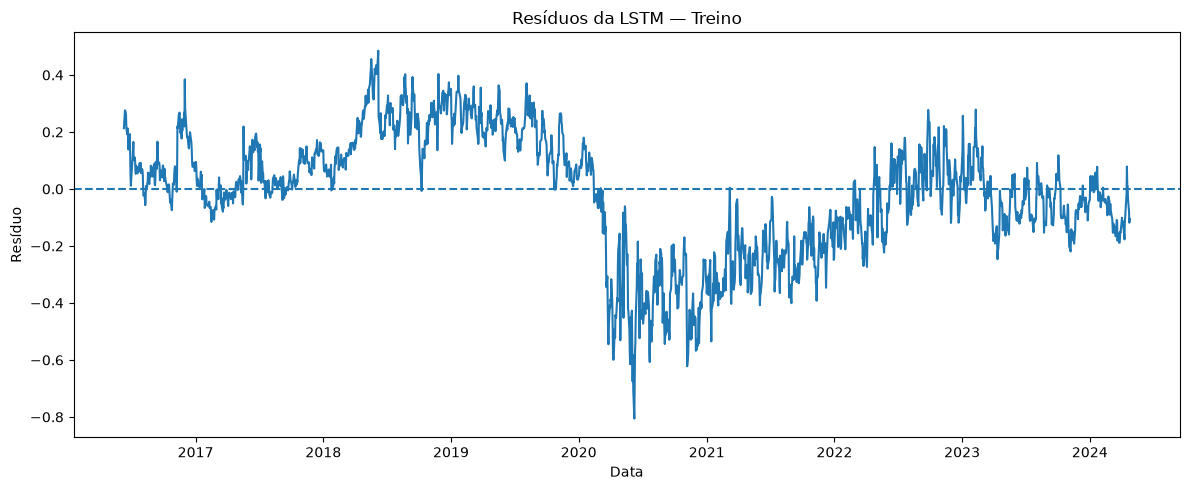

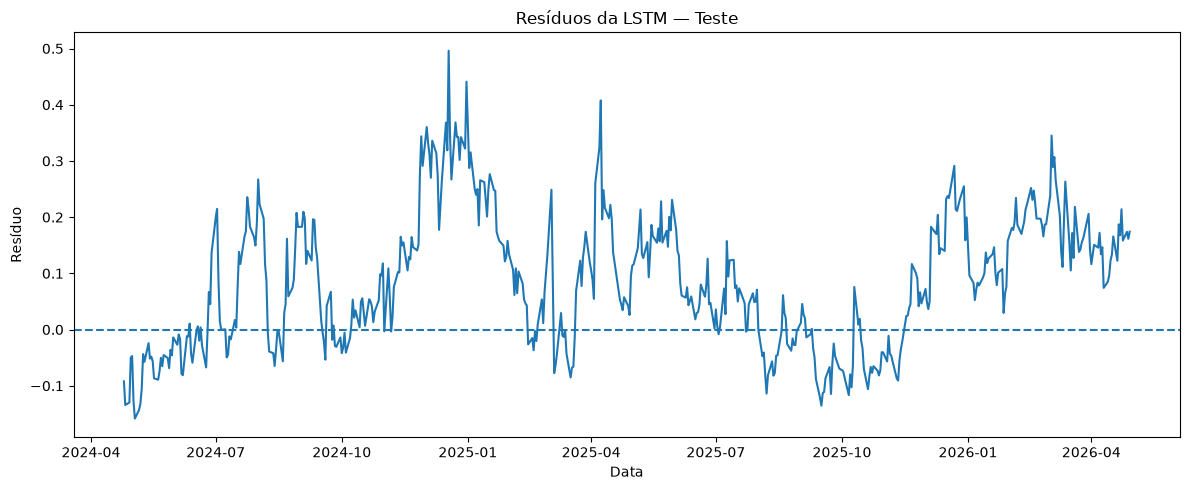

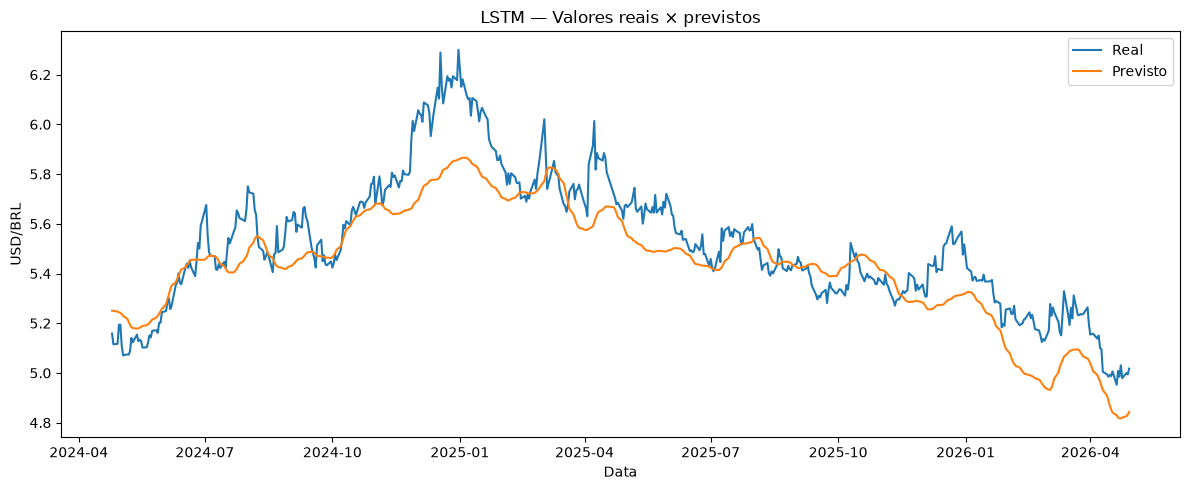

[OK] Diagnósticos gráficos salvos.


In [27]:
residuos_treino = y_train_real - y_pred_train
residuos_teste = y_test_real - y_pred_test

residuos_treino_df = pd.DataFrame({
    "Data": datas_train_seq,
    "Real": y_train_real,
    "Previsto": y_pred_train,
    "Residuo": residuos_treino
})

residuos_teste_df = pd.DataFrame({
    "Data": datas_test_seq,
    "Real": y_test_real,
    "Previsto": y_pred_test,
    "Residuo": residuos_teste
})

residuos_treino_df.to_csv(
    PATH_TO_SAVE / "residuos_treino.csv",
    index=False
)

residuos_teste_df.to_csv(
    PATH_TO_SAVE / "residuos_teste.csv",
    index=False
)

# Resíduos — treino
plt.figure(figsize=(12, 5))
plt.plot(datas_train_seq, residuos_treino)
plt.axhline(y=0, linestyle="--")
plt.title("Resíduos da LSTM — Treino")
plt.xlabel("Data")
plt.ylabel("Resíduo")
plt.tight_layout()
plt.savefig(PATH_TO_SAVE / "grafico_residuos_treino.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Resíduos — teste
plt.figure(figsize=(12, 5))
plt.plot(datas_test_seq, residuos_teste)
plt.axhline(y=0, linestyle="--")
plt.title("Resíduos da LSTM — Teste")
plt.xlabel("Data")
plt.ylabel("Resíduo")
plt.tight_layout()
plt.savefig(PATH_TO_SAVE / "grafico_residuos_teste.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Real x previsto — teste
plt.figure(figsize=(12, 5))
plt.plot(datas_test_seq, y_test_real, label="Real")
plt.plot(datas_test_seq, y_pred_test, label="Previsto")
plt.title("LSTM — Valores reais × previstos")
plt.xlabel("Data")
plt.ylabel("USD/BRL")
plt.legend()
plt.tight_layout()
plt.savefig(PATH_TO_SAVE / "grafico_real_vs_previsto.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("[OK] Diagnósticos gráficos salvos.")

## Etapa 11 — Avaliação do modelo

São calculadas MAE, RMSE e R² para treino e teste. Para a comparação entre modelos, o conjunto de teste é o principal referência.

In [28]:
metricas = pd.DataFrame({
    "Modelo": ["LSTM", "LSTM"],
    "Conjunto": ["Treino", "Teste"],
    "MAE": [
        mean_absolute_error(y_train_real, y_pred_train),
        mean_absolute_error(y_test_real, y_pred_test)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_real, y_pred_train)),
        np.sqrt(mean_squared_error(y_test_real, y_pred_test))
    ],
    "R2": [
        r2_score(y_train_real, y_pred_train),
        r2_score(y_test_real, y_pred_test)
    ]
})

print("\nMÉTRICAS")
print(metricas.to_string(index=False))

metricas.to_csv(
    PATH_TO_SAVE / "metricas_lstm.csv",
    index=False
)

print("[OK] Métricas salvas.")


MÉTRICAS
Modelo Conjunto      MAE     RMSE       R2
  LSTM   Treino 0.168168 0.213019 0.940202
  LSTM    Teste 0.113702 0.143766 0.711375
[OK] Métricas salvas.


## Etapa 12 — Histórico do treinamento

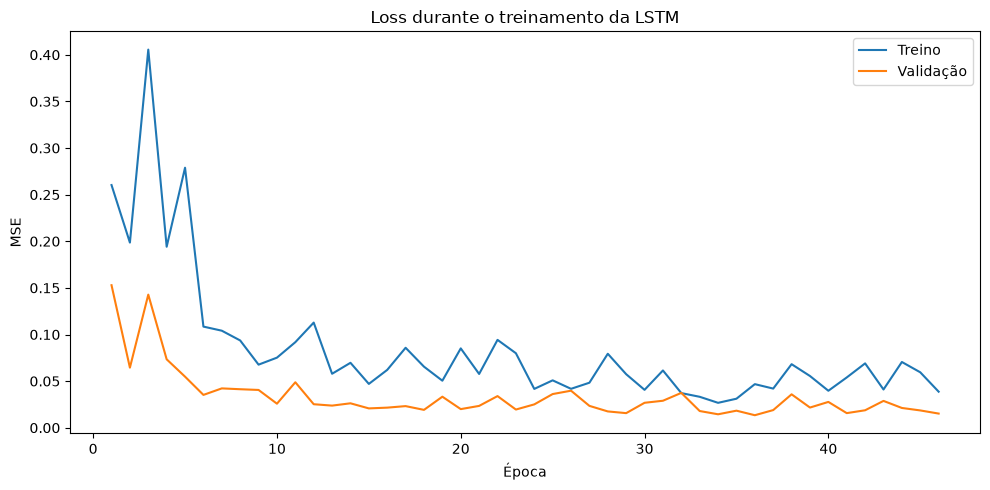

[OK] Histórico e gráfico de loss salvos.


In [29]:
historico_df = pd.DataFrame(historico.history)
historico_df.insert(
    0,
    "Epoch",
    range(1, len(historico_df) + 1)
)

historico_df.to_csv(
    PATH_TO_SAVE / "historico_treinamento.csv",
    index=False
)

plt.figure(figsize=(10, 5))
plt.plot(historico_df["Epoch"], historico_df["loss"], label="Treino")
if "val_loss" in historico_df.columns:
    plt.plot(historico_df["Epoch"], historico_df["val_loss"], label="Validação")

plt.title("Loss durante o treinamento da LSTM")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.savefig(PATH_TO_SAVE / "loss_treinamento.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("[OK] Histórico e gráfico de loss salvos.")

## Etapa 13 — Salvamento das previsões e do modelo

In [30]:
previsoes_treino = pd.DataFrame({
    "Data": datas_train_seq,
    "Real": y_train_real,
    "Previsto": y_pred_train
})

previsoes_teste = pd.DataFrame({
    "Data": datas_test_seq,
    "Real": y_test_real,
    "Previsto": y_pred_test
})

previsoes_treino.to_csv(
    PATH_TO_SAVE / "previsoes_treino.csv",
    index=False
)

previsoes_teste.to_csv(
    PATH_TO_SAVE / "previsoes_teste.csv",
    index=False
)

modelo_lstm.save(
    PATH_TO_SAVE / "lstm_model.keras"
)

print("[OK] Previsões de treino salvas.")
print("[OK] Previsões de teste salvas.")
print("[OK] Modelo LSTM salvo.")

[OK] Previsões de treino salvas.
[OK] Previsões de teste salvas.
[OK] Modelo LSTM salvo.


## Etapa 14 — Relatório do experimento

In [31]:
relatorio = f"""# LSTM

## Configuração experimental

- Configuração: {"Experimento com USD/BRL(t)" if EXPERIMENTO_USD_T else "Modelo principal"}
- Target: `USD_BRL_t1`
- Janela temporal: {WINDOW} observações
- Divisão temporal: 80% treino / 20% teste
- Padronização: StandardScaler para X e y
- Scalers ajustados somente no treino
- Epochs máximas: 100
- Batch size: 32
- EarlyStopping: patience=10
- restore_best_weights=True
- shuffle=False
- Otimizador: Adam
- Loss: MSE

## Arquitetura

- LSTM(64)
- Dropout(0.2)
- LSTM(32)
- Dropout(0.2)
- Dense(16)
- Dense(1)

## Períodos

- Treino: {X_train.index.min().date()} a {X_train.index.max().date()}
- Teste: {X_test.index.min().date()} a {X_test.index.max().date()}

## Métricas

{metricas.to_markdown(index=False)}

## Observação sobre as sequências

A primeira sequência de teste foi construída com as últimas {WINDOW-1} observações de treino e a primeira observação de teste. A observação de teste é utilizada como informação disponível em t para prever o target USD/BRL(t+1), evitando o uso de informação futura.
"""

with open(PATH_TO_SAVE / "lstm.md", "w", encoding="utf-8") as arquivo:
    arquivo.write(relatorio)

print("[OK] Relatório salvo em:")
print(PATH_TO_SAVE / "lstm.md")

[OK] Relatório salvo em:
C:\Projetos\PTAX_PREDICTION_MBA_TCC\resultados\lstm\experimento_usd_t\lstm.md


## Etapa 15 — Validação final dos arquivos gerados

In [32]:
arquivos_esperados = [
    "standard_scaler_X.joblib",
    "standard_scaler_y.joblib",
    "lstm_model.keras",
    "historico_treinamento.csv",
    "loss_treinamento.png",
    "metricas_lstm.csv",
    "previsoes_treino.csv",
    "previsoes_teste.csv",
    "residuos_treino.csv",
    "residuos_teste.csv",
    "grafico_residuos_treino.png",
    "grafico_residuos_teste.png",
    "grafico_real_vs_previsto.png",
    "lstm.md"
]

print("=" * 70)
print("VALIDAÇÃO FINAL")
print("=" * 70)

faltantes = []

for nome in arquivos_esperados:
    caminho = PATH_TO_SAVE / nome
    if caminho.exists():
        print(f"[OK] {nome}")
    else:
        print(f"[ERRO] {nome}")
        faltantes.append(nome)

if faltantes:
    raise FileNotFoundError(
        f"Arquivos esperados não encontrados: {faltantes}"
    )

print("\n[OK] Todos os arquivos esperados foram gerados.")

VALIDAÇÃO FINAL
[OK] standard_scaler_X.joblib
[OK] standard_scaler_y.joblib
[OK] lstm_model.keras
[OK] historico_treinamento.csv
[OK] loss_treinamento.png
[OK] metricas_lstm.csv
[OK] previsoes_treino.csv
[OK] previsoes_teste.csv
[OK] residuos_treino.csv
[OK] residuos_teste.csv
[OK] grafico_residuos_treino.png
[OK] grafico_residuos_teste.png
[OK] grafico_real_vs_previsto.png
[OK] lstm.md

[OK] Todos os arquivos esperados foram gerados.
